<h1 style="color:white; background-color:blue; padding:20px; border-radius:20px; text-align:center;">
Filtre de Hanning & Loi Normale Asymétrique (Skew-Normal)
</h1>

<h2 style="color:white; background-color:blue; padding:20px; border-radius:20px; text-align:center;">
Analyse des 10 sociétés du Secteur Aéronautique (Aerospace)
</h2>

# Company Analysis B : HON, LMT, RTX


### 0. Imports

In [1]:
# rtx_df["Y_t"] = (
#     0.25 * rtx_df["X_t"].shift(1) +
#     0.50 * rtx_df["X_t"] +
#     0.25 * rtx_df["X_t"].shift(-1)
# )
# rtx_df = rtx_df.dropna().reset_index(drop=True)

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, norm
from scipy.optimize import minimize

### 1. Load Data

In [3]:
START_DATE = "2023-01-04"
DATA_DIR   = "../../data/Secteur_Aerospace"
OUTPUT_DIR = "../json"


import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

hon_df = pd.read_csv(f"{DATA_DIR}/HON.csv")
hon_df = hon_df[["Date", "Adj Close"]].copy()
hon_df.columns = ["Date", "X_t"]

lmt_df = pd.read_csv(f"{DATA_DIR}/LMT.csv")
lmt_df = lmt_df[["Date", "Adj Close"]].copy()
lmt_df.columns = ["Date", "X_t"]

rtx_df = pd.read_csv(f"{DATA_DIR}/RTX.csv")
rtx_df = rtx_df[["Date", "Adj Close"]].copy()
rtx_df.columns = ["Date", "X_t"]

### 2. Clean Data

In [4]:
hon_df["Date"] = pd.to_datetime(hon_df["Date"])
hon_df = hon_df[hon_df["Date"] >= pd.Timestamp(START_DATE)].copy()
hon_df = hon_df.sort_values("Date").dropna().reset_index(drop=True)

lmt_df["Date"] = pd.to_datetime(lmt_df["Date"])
lmt_df = lmt_df[lmt_df["Date"] >= pd.Timestamp(START_DATE)].copy()
lmt_df = lmt_df.sort_values("Date").dropna().reset_index(drop=True)

rtx_df["Date"] = pd.to_datetime(rtx_df["Date"])
rtx_df = rtx_df[rtx_df["Date"] >= pd.Timestamp(START_DATE)].copy()
rtx_df = rtx_df.sort_values("Date").dropna().reset_index(drop=True)

print("HON shape:", hon_df.shape)
print("LMT  shape:", lmt_df.shape)
print("RTX  shape:", lmt_df.shape)

HON shape: (770, 2)
LMT  shape: (770, 2)
RTX  shape: (770, 2)


### 3. Hanning Filter
$$Y_t = \frac{1}{4}X_{t-1} + \frac{1}{2}X_t + \frac{1}{4}X_{t+1}$$

In [5]:
hon_df["Y_t"] = (
    0.25 * hon_df["X_t"].shift(1) +
    0.50 * hon_df["X_t"] +
    0.25 * hon_df["X_t"].shift(-1)
)
hon_df = hon_df.dropna().reset_index(drop=True)

lmt_df["Y_t"] = (
    0.25 * lmt_df["X_t"].shift(1) +
    0.50 * lmt_df["X_t"] +
    0.25 * lmt_df["X_t"].shift(-1)
)
lmt_df = lmt_df.dropna().reset_index(drop=True)

rtx_df["Y_t"] = (
    0.25 * rtx_df["X_t"].shift(1) +
    0.50 * rtx_df["X_t"] +
    0.25 * rtx_df["X_t"].shift(-1)
)
rtx_df = rtx_df.dropna().reset_index(drop=True)

**Plot Raw Series vs Hanning Filtered — HON**

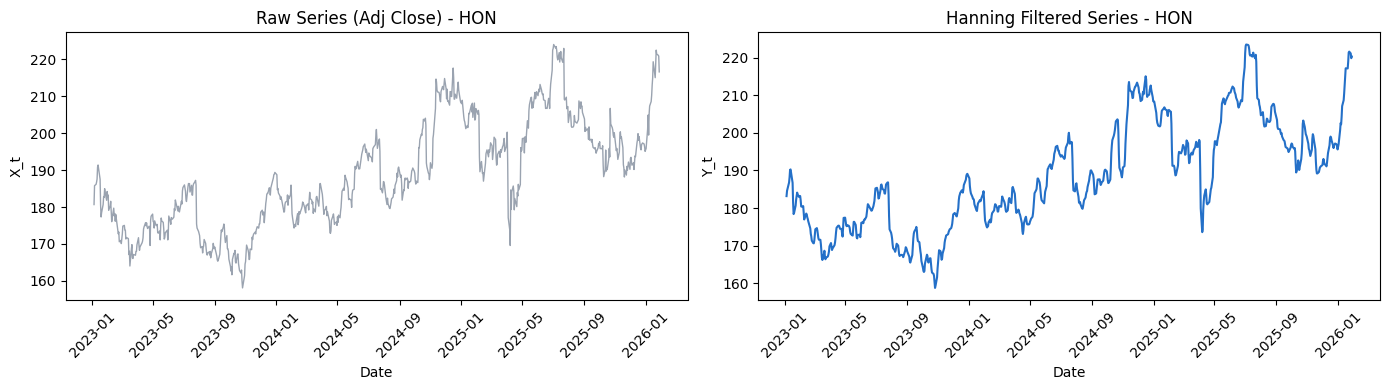

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hon_df["Date"], hon_df["X_t"], color='#9AA3B0', lw=1)
axes[0].set_title("Raw Series (Adj Close) - HON")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("X_t")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].plot(hon_df["Date"], hon_df["Y_t"], color='#2470C8', lw=1.5)
axes[1].set_title("Hanning Filtered Series - HON")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Y_t")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

**Plot Raw Series vs Hanning Filtered — LMT**

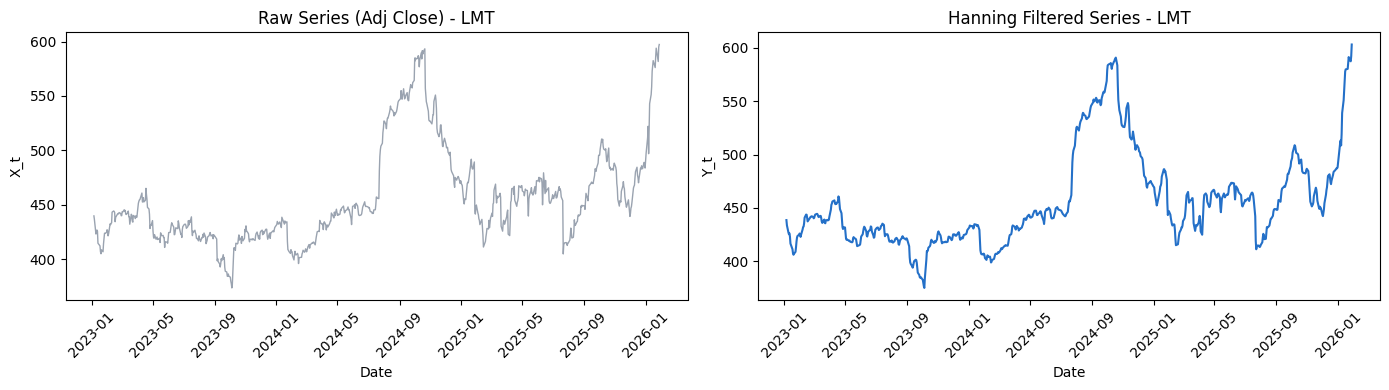

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(lmt_df["Date"], lmt_df["X_t"], color='#9AA3B0', lw=1)
axes[0].set_title("Raw Series (Adj Close) - LMT")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("X_t")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].plot(lmt_df["Date"], lmt_df["Y_t"], color='#2470C8', lw=1.5)
axes[1].set_title("Hanning Filtered Series - LMT")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Y_t")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

**Plot Raw Series vs Hanning Filtered — RTX**

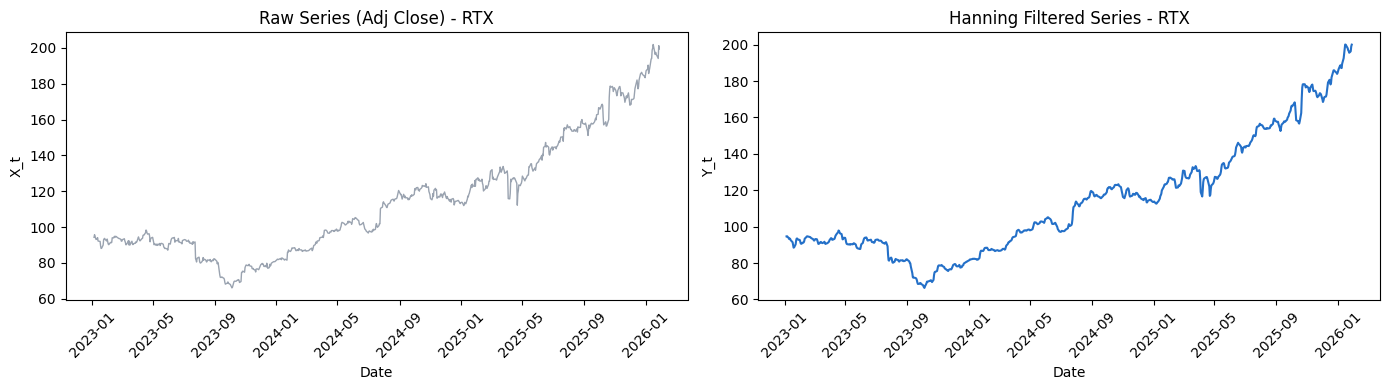

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rtx_df["Date"], rtx_df["X_t"], color='#9AA3B0', lw=1)
axes[0].set_title("Raw Series (Adj Close) - RTX")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("X_t")
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

axes[1].plot(rtx_df["Date"], rtx_df["Y_t"], color='#2470C8', lw=1.5)
axes[1].set_title("Hanning Filtered Series - RTX")
axes[1].set_xlabel("Date"); axes[1].set_ylabel("Y_t")
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### 4. Define Skew-Normal PDF and MLE functions

In [9]:
def skew_normal_pdf(x, mu, sigma, theta):
    z = (x - mu) / sigma
    return (2.0 / sigma) * norm.pdf(z) * norm.cdf(theta * z)


def neg_loglik_common_theta(params, y_left, y_right):
    """
    params = [mu1, log_sigma1, mu2, log_sigma2, theta]
    Common theta across both segments, as required by Sujet 3.
    """
    mu1, log_sigma1, mu2, log_sigma2, theta = params
    sigma1 = np.exp(log_sigma1)
    sigma2 = np.exp(log_sigma2)

    if sigma1 <= 0 or sigma2 <= 0 or not np.isfinite(theta):
        return np.inf

    pdf1 = np.clip(skew_normal_pdf(y_left,  mu1, sigma1, theta), 1e-12, None)
    pdf2 = np.clip(skew_normal_pdf(y_right, mu2, sigma2, theta), 1e-12, None)

    return -(np.sum(np.log(pdf1)) + np.sum(np.log(pdf2)))


def fit_sn_two_regimes(Y, k):
    """Fit SN MLE on both segments with common theta."""
    y1 = Y[:k]
    y2 = Y[k:]

    mu1_init    = float(np.mean(y1))
    mu2_init    = float(np.mean(y2))
    sigma1_init = max(float(np.std(y1, ddof=0)), 1e-3)
    sigma2_init = max(float(np.std(y2, ddof=0)), 1e-3)

    x0 = np.array([mu1_init, np.log(sigma1_init),
                   mu2_init, np.log(sigma2_init), 0.0])

    result = minimize(
        neg_loglik_common_theta,
        x0=x0, args=(y1, y2), method="L-BFGS-B"
    )
    if not result.success:
        print("Warning: optimization did not fully converge.")
        print("Message:", result.message)

    mu1_hat, ls1, mu2_hat, ls2, theta_hat = result.x
    return {
        "mu1"   : float(mu1_hat),
        "sigma1": float(np.exp(ls1)),
        "mu2"   : float(mu2_hat),
        "sigma2": float(np.exp(ls2)),
        "theta" : float(theta_hat),
        "n1"    : len(y1),
        "n2"    : len(y2),
        "negll" : float(result.fun),
    }

---
## HON

### 5. KS Scan over k — HON

In [10]:
Y = hon_df["Y_t"].to_numpy()
n = len(Y)

k_values, ks_stats, p_values = [], [], []

for k in range(30, n - 29):
    stat, pval = ks_2samp(Y[:k], Y[k:])
    k_values.append(k)
    ks_stats.append(stat)
    p_values.append(pval)

best_index = int(np.argmax(ks_stats))
k_hat      = k_values[best_index]
best_ks    = float(ks_stats[best_index])
best_pval  = float(p_values[best_index])
break_date = hon_df.loc[k_hat, "Date"]

print("Best rupture point from KS scan")
print("k_hat      =", k_hat)
print("break_date =", break_date.date())
print("KS stat    =", best_ks)
print("p-value    =", best_pval)

Best rupture point from KS scan
k_hat      = 354
break_date = 2024-06-04
KS stat    = 0.8634242200933432
p-value    = 7.186927914119217e-148


**KS Scan Plot — HON**

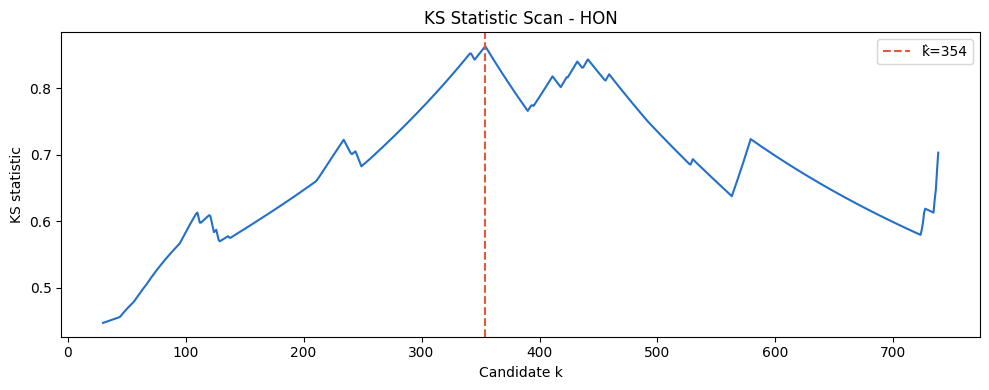

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(k_values, ks_stats, color='#2470C8', lw=1.5)
plt.axvline(k_hat, color='#E05A3A', linestyle='--', label=f'k̂={k_hat}')
plt.title("KS Statistic Scan - HON")
plt.xlabel("Candidate k"); plt.ylabel("KS statistic")
plt.legend(); plt.tight_layout(); plt.show()

**Breakpoint Detection Plot — HON**

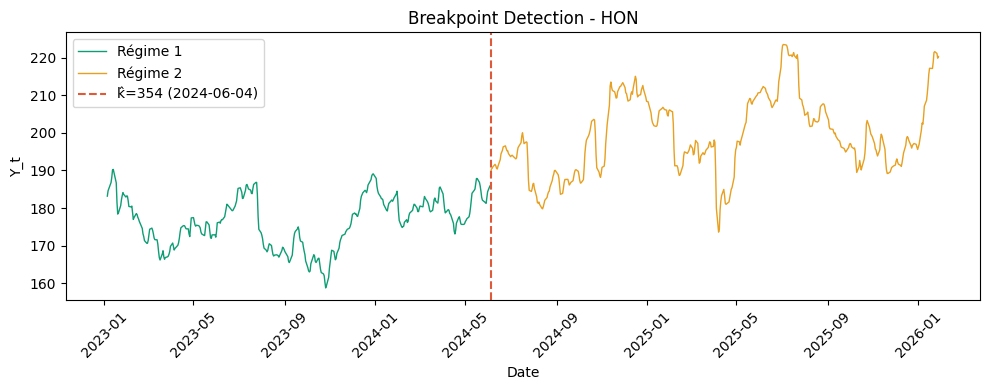

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(hon_df["Date"][:k_hat], Y[:k_hat], color='#0E9E74', lw=1, label='Régime 1')
plt.plot(hon_df["Date"][k_hat:], Y[k_hat:], color='#E8A020', lw=1, label='Régime 2')
plt.axvline(break_date, color='#E05A3A', linestyle='--', label=f'k̂={k_hat} ({break_date.date()})')
plt.title("Breakpoint Detection - HON")
plt.xlabel("Date"); plt.ylabel("Y_t")
plt.xticks(rotation=45); plt.legend(); plt.tight_layout(); plt.show()

### 6. Estimate Skew-Normal Parameters — HON

In [13]:
sn_hon = fit_sn_two_regimes(Y, k_hat)

mu1_hat    = sn_hon['mu1']
sigma1_hat = sn_hon['sigma1']
mu2_hat    = sn_hon['mu2']
sigma2_hat = sn_hon['sigma2']
theta_hat  = sn_hon['theta']

print("Joint MLE estimates with common theta")
print("mu1    =", mu1_hat)
print("sigma1 =", sigma1_hat)
print("mu2    =", mu2_hat)
print("sigma2 =", sigma2_hat)
print("theta  =", theta_hat)
print("NegLogLik =", sn_hon['negll'])

Joint MLE estimates with common theta
mu1    = 176.28628891242937
sigma1 = 6.6807059842526035
mu2    = 199.02578315217394
sigma2 = 10.174685019306732
theta  = 0.0
NegLogLik = 2722.509716633812


In [14]:
verdict_hon = "Reject H0" if best_pval < 0.05 else "Fail to reject H0"
print("Verdict:", verdict_hon)

Verdict: Reject H0


**SN Density Fit — HON**

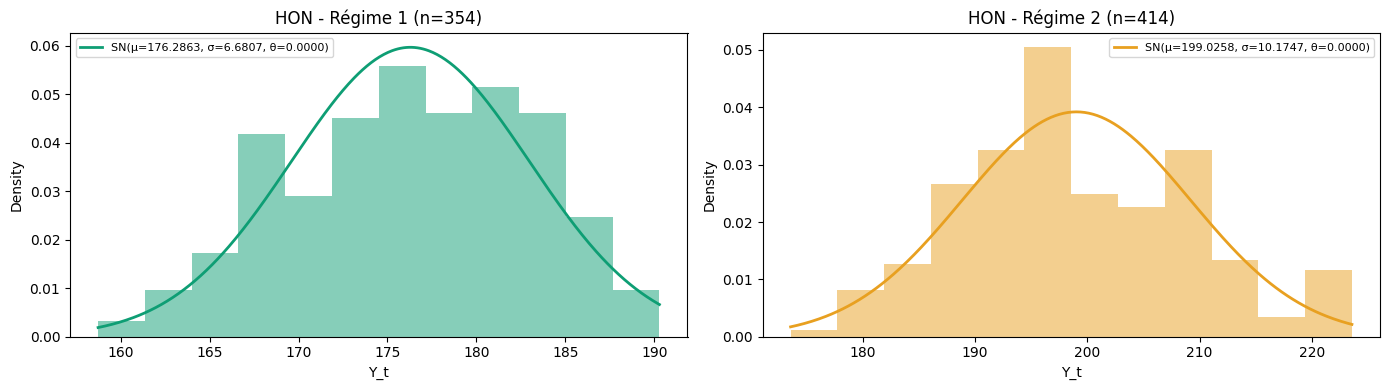

In [15]:
y1 = Y[:k_hat]
y2 = Y[k_hat:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, seg, mu, sigma, color, label in [
    (axes[0], y1, mu1_hat, sigma1_hat, '#0E9E74', f'Régime 1 (n={len(y1)})'),
    (axes[1], y2, mu2_hat, sigma2_hat, '#E8A020', f'Régime 2 (n={len(y2)})'),
]:
    x_grid = np.linspace(np.min(seg), np.max(seg), 400)
    ax.hist(seg, bins=12, density=True, alpha=0.5, color=color)
    ax.plot(x_grid, skew_normal_pdf(x_grid, mu, sigma, theta_hat),
            color=color, lw=2,
            label=f'SN(μ={mu:.4f}, σ={sigma:.4f}, θ={theta_hat:.4f})')
    ax.set_title(f'HON - {label}')
    ax.set_xlabel('Y_t'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Interpretation — HON

In [16]:
interpretation_hon = (
    f"For HON, the estimated rupture point is k_hat = {k_hat} "
    f"({break_date.date()}). The KS statistic is {best_ks:.4f} and the "
    f"p-value is {best_pval:.4f}, so the decision is: {verdict_hon}. "
    f"The joint MLE estimates are mu1 = {mu1_hat:.4f}, sigma1 = {sigma1_hat:.4f}, "
    f"mu2 = {mu2_hat:.4f}, sigma2 = {sigma2_hat:.4f}, theta = {theta_hat:.4f}."
)
print(interpretation_hon)

For HON, the estimated rupture point is k_hat = 354 (2024-06-04). The KS statistic is 0.8634 and the p-value is 0.0000, so the decision is: Reject H0. The joint MLE estimates are mu1 = 176.2863, sigma1 = 6.6807, mu2 = 199.0258, sigma2 = 10.1747, theta = 0.0000.


**Save Result as JSON — HON**

In [17]:
# SN density curves for Plotly
xg1  = np.linspace(y1.min()-0.004, y1.max()+0.004, 300).tolist()
pdf1 = skew_normal_pdf(np.array(xg1), mu1_hat, sigma1_hat, theta_hat).tolist()
xg2  = np.linspace(y2.min()-0.004, y2.max()+0.004, 300).tolist()
pdf2 = skew_normal_pdf(np.array(xg2), mu2_hat, sigma2_hat, theta_hat).tolist()

hon_results = {
    "company"       : "HON",
    "name"          : "Airbus",
    "url"           : "https://fr.finance.yahoo.com/quote/HON/profile",
    "k_hat"         : int(k_hat),
    "bp_date"       : str(break_date.date()),
    "D"             : round(best_ks, 5),
    "p_value"       : round(best_pval, 6),
    "reject_H0"     : bool(best_pval < 0.05),
    "verdict"       : verdict_hon,
    "mu1"           : round(mu1_hat, 6),
    "sigma1"        : round(sigma1_hat, 6),
    "mu2"           : round(mu2_hat, 6),
    "sigma2"        : round(sigma2_hat, 6),
    "theta"         : round(theta_hat, 6),
    "n1"            : sn_hon['n1'],
    "n2"            : sn_hon['n2'],
    "interpretation": interpretation_hon,
    "chart_data"    : {
        "dates"   : hon_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "prices"  : hon_df["X_t"].tolist(),
        "sm_dates": hon_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "smoothed": hon_df["Y_t"].tolist(),
        "Y_dates" : hon_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "Y"       : Y.tolist(),
        "xg1": xg1, "pdf1": pdf1,
        "xg2": xg2, "pdf2": pdf2,
        "scan_k"  : k_values,
        "scan_D"  : ks_stats,
        "scan_p"  : p_values,
    }
}

with open(f"{OUTPUT_DIR}/HON.json", "w", encoding="utf-8") as f:
    json.dump(hon_results, f, indent=4, ensure_ascii=False)
print("Saved -> results/json/HON.json")

Saved -> results/json/HON.json


---
## LMT

### 5. KS Scan over k — LMT

In [18]:
Y = lmt_df["Y_t"].to_numpy()
n = len(Y)

k_values, ks_stats, p_values = [], [], []

for k in range(30, n - 29):
    stat, pval = ks_2samp(Y[:k], Y[k:])
    k_values.append(k)
    ks_stats.append(stat)
    p_values.append(pval)

best_index = int(np.argmax(ks_stats))
k_hat      = k_values[best_index]
best_ks    = float(ks_stats[best_index])
best_pval  = float(p_values[best_index])
break_date = lmt_df.loc[k_hat, "Date"]

print("Best rupture point from KS scan")
print("k_hat      =", k_hat)
print("break_date =", break_date.date())
print("KS stat    =", best_ks)
print("p-value    =", best_pval)

Best rupture point from KS scan
k_hat      = 736
break_date = 2025-12-11
KS stat    = 0.7934782608695652
p-value    = 7.387635503577363e-21


**KS Scan Plot and Breakpoint Plot — LMT**

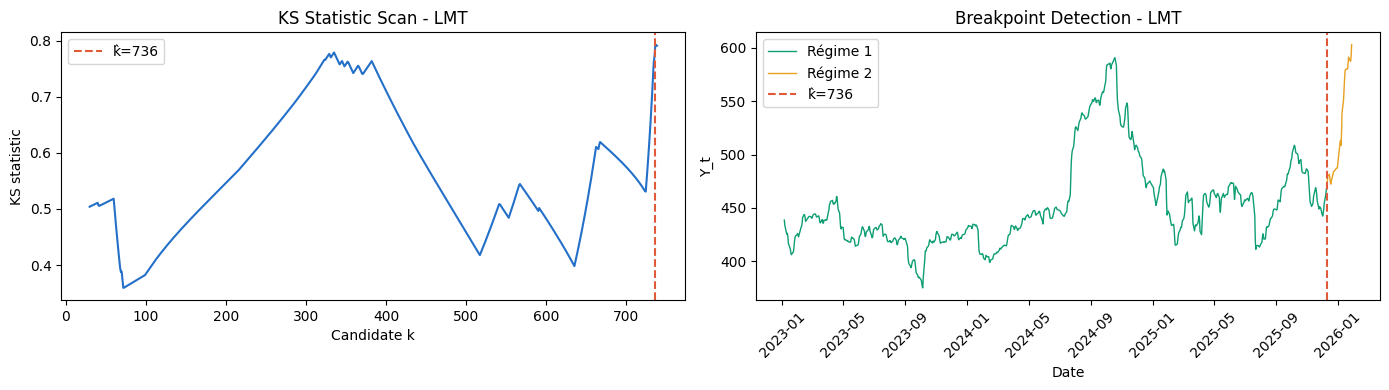

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(k_values, ks_stats, color='#2470C8', lw=1.5)
axes[0].axvline(k_hat, color='#E05A3A', linestyle='--', label=f'k̂={k_hat}')
axes[0].set_title(f'KS Statistic Scan - LMT')
axes[0].set_xlabel('Candidate k'); axes[0].set_ylabel('KS statistic')
axes[0].legend()

axes[1].plot(lmt_df["Date"][:k_hat], Y[:k_hat], color='#0E9E74', lw=1, label='Régime 1')
axes[1].plot(lmt_df["Date"][k_hat:], Y[k_hat:], color='#E8A020', lw=1, label='Régime 2')
axes[1].axvline(break_date, color='#E05A3A', linestyle='--', label=f'k̂={k_hat}')
axes[1].set_title('Breakpoint Detection - LMT')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Y_t')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
axes[1].legend()
plt.tight_layout(); plt.show()

### 6. Estimate Skew-Normal Parameters — LMT

In [20]:
sn_lmt = fit_sn_two_regimes(Y, k_hat)

mu1_hat    = sn_lmt['mu1']
sigma1_hat = sn_lmt['sigma1']
mu2_hat    = sn_lmt['mu2']
sigma2_hat = sn_lmt['sigma2']
theta_hat  = sn_lmt['theta']

print("Joint MLE estimates with common theta")
print("mu1    =", mu1_hat)
print("sigma1 =", sigma1_hat)
print("mu2    =", mu2_hat)
print("sigma2 =", sigma2_hat)
print("theta  =", theta_hat)
print("NegLogLik =", sn_lmt['negll'])

Joint MLE estimates with common theta
mu1    = 452.3714060809949
sigma1 = 41.85377271761395
mu2    = 524.62671875
sigma2 = 46.31604663561159
theta  = 8.318342115654876e-10
NegLogLik = 3960.8383331706186


In [21]:
verdict_lmt = "Reject H0" if best_pval < 0.05 else "Fail to reject H0"
print("Verdict:", verdict_lmt)

Verdict: Reject H0


**SN Density Fit — LMT**

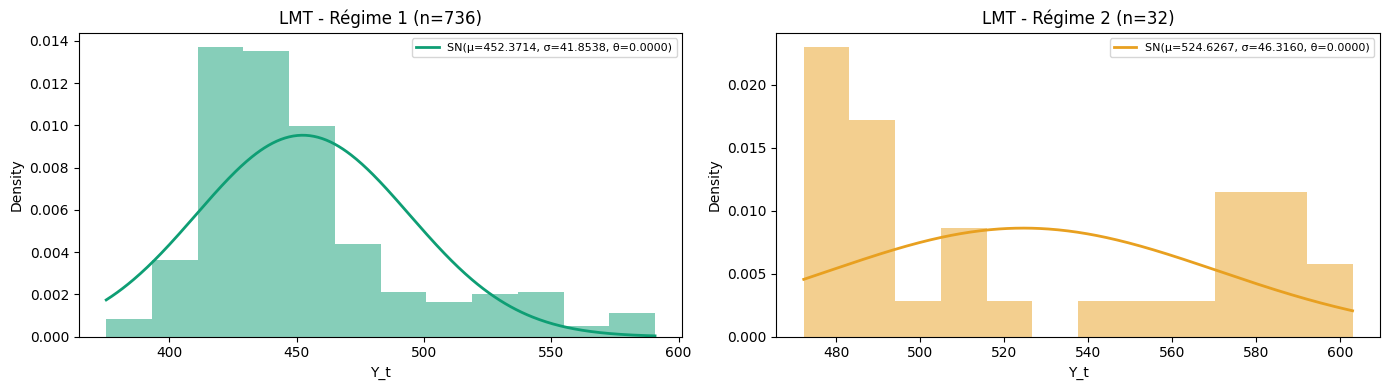

In [22]:
y1 = Y[:k_hat]
y2 = Y[k_hat:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, seg, mu, sigma, color, label in [
    (axes[0], y1, mu1_hat, sigma1_hat, '#0E9E74', f'Régime 1 (n={len(y1)})'),
    (axes[1], y2, mu2_hat, sigma2_hat, '#E8A020', f'Régime 2 (n={len(y2)})'),
]:
    x_grid = np.linspace(np.min(seg), np.max(seg), 400)
    ax.hist(seg, bins=12, density=True, alpha=0.5, color=color)
    ax.plot(x_grid, skew_normal_pdf(x_grid, mu, sigma, theta_hat),
            color=color, lw=2,
            label=f'SN(μ={mu:.4f}, σ={sigma:.4f}, θ={theta_hat:.4f})')
    ax.set_title(f'LMT - {label}')
    ax.set_xlabel('Y_t'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Interpretation — LMT

In [23]:
interpretation_lmt = (
    f"For LMT, the estimated rupture point is k_hat = {k_hat} "
    f"({break_date.date()}). The KS statistic is {best_ks:.4f} and the "
    f"p-value is {best_pval:.4f}, so the decision is: {verdict_lmt}. "
    f"The joint MLE estimates are mu1 = {mu1_hat:.4f}, sigma1 = {sigma1_hat:.4f}, "
    f"mu2 = {mu2_hat:.4f}, sigma2 = {sigma2_hat:.4f}, theta = {theta_hat:.4f}."
)
print(interpretation_lmt)

For LMT, the estimated rupture point is k_hat = 736 (2025-12-11). The KS statistic is 0.7935 and the p-value is 0.0000, so the decision is: Reject H0. The joint MLE estimates are mu1 = 452.3714, sigma1 = 41.8538, mu2 = 524.6267, sigma2 = 46.3160, theta = 0.0000.


**Save Result as JSON — LMT**

In [24]:
xg1  = np.linspace(y1.min()-0.004, y1.max()+0.004, 300).tolist()
pdf1 = skew_normal_pdf(np.array(xg1), mu1_hat, sigma1_hat, theta_hat).tolist()
xg2  = np.linspace(y2.min()-0.004, y2.max()+0.004, 300).tolist()
pdf2 = skew_normal_pdf(np.array(xg2), mu2_hat, sigma2_hat, theta_hat).tolist()

lmt_results = {
    "company"       : "LMT",
    "name"          : "Dassault Aviation",
    "url"           : "https://fr.finance.yahoo.com/quote/LMT/profile",
    "k_hat"         : int(k_hat),
    "bp_date"       : str(break_date.date()),
    "D"             : round(best_ks, 5),
    "p_value"       : round(best_pval, 6),
    "reject_H0"     : bool(best_pval < 0.05),
    "verdict"       : verdict_lmt,
    "mu1"           : round(mu1_hat, 6),
    "sigma1"        : round(sigma1_hat, 6),
    "mu2"           : round(mu2_hat, 6),
    "sigma2"        : round(sigma2_hat, 6),
    "theta"         : round(theta_hat, 6),
    "n1"            : sn_lmt['n1'],
    "n2"            : sn_lmt['n2'],
    "interpretation": interpretation_lmt,
    "chart_data"    : {
        "dates"   : lmt_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "prices"  : lmt_df["X_t"].tolist(),
        "sm_dates": lmt_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "smoothed": lmt_df["Y_t"].tolist(),
        "Y_dates" : lmt_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "Y"       : Y.tolist(),
        "xg1": xg1, "pdf1": pdf1,
        "xg2": xg2, "pdf2": pdf2,
        "scan_k"  : k_values,
        "scan_D"  : ks_stats,
        "scan_p"  : p_values,
    }
}

with open(f"{OUTPUT_DIR}/LMT.json", "w", encoding="utf-8") as f:
    json.dump(lmt_results, f, indent=4, ensure_ascii=False)
print("Saved -> results/json/LMT.json")

Saved -> results/json/LMT.json


---
## RTX

### 5. KS Scan over k — RTX

In [25]:
Y = rtx_df["Y_t"].to_numpy()
n = len(Y)

k_values, ks_stats, p_values = [], [], []

for k in range(30, n - 29):
    stat, pval = ks_2samp(Y[:k], Y[k:])
    k_values.append(k)
    ks_stats.append(stat)
    p_values.append(pval)

best_index = int(np.argmax(ks_stats))
k_hat      = k_values[best_index]
best_ks    = float(ks_stats[best_index])
best_pval  = float(p_values[best_index])
break_date = rtx_df.loc[k_hat, "Date"]

print("Best rupture point from KS scan")
print("k_hat      =", k_hat)
print("break_date =", break_date.date())
print("KS stat    =", best_ks)
print("p-value    =", best_pval)

Best rupture point from KS scan
k_hat      = 389
break_date = 2024-07-25
KS stat    = 1.0
p-value    = 4.776542416399053e-230


**KS Scan Plot and Breakpoint Plot — RTX**

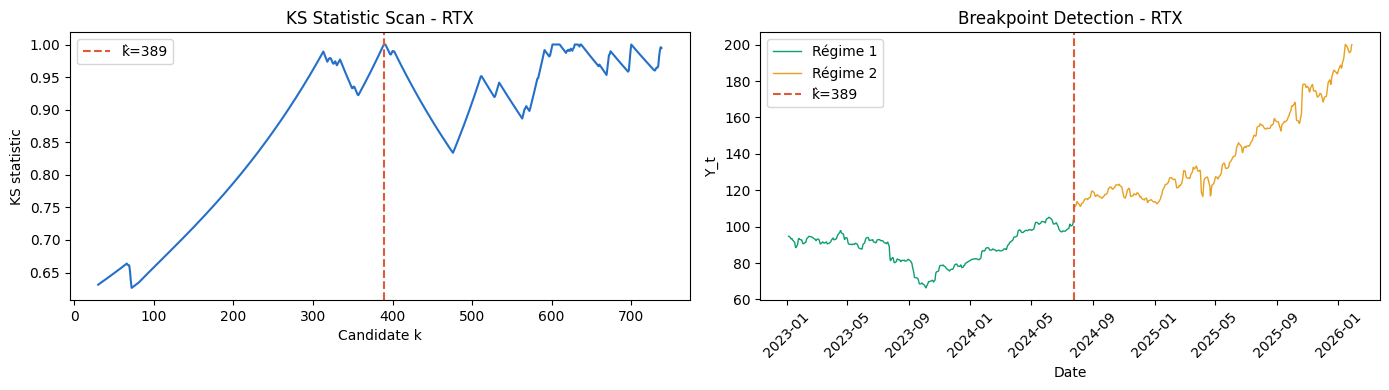

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(k_values, ks_stats, color='#2470C8', lw=1.5)
axes[0].axvline(k_hat, color='#E05A3A', linestyle='--', label=f'k̂={k_hat}')
axes[0].set_title(f'KS Statistic Scan - RTX')
axes[0].set_xlabel('Candidate k'); axes[0].set_ylabel('KS statistic')
axes[0].legend()

axes[1].plot(rtx_df["Date"][:k_hat], Y[:k_hat], color='#0E9E74', lw=1, label='Régime 1')
axes[1].plot(rtx_df["Date"][k_hat:], Y[k_hat:], color='#E8A020', lw=1, label='Régime 2')
axes[1].axvline(break_date, color='#E05A3A', linestyle='--', label=f'k̂={k_hat}')
axes[1].set_title('Breakpoint Detection - RTX')
axes[1].set_xlabel('Date'); axes[1].set_ylabel('Y_t')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
axes[1].legend()
plt.tight_layout(); plt.show()

### 6. Estimate Skew-Normal Parameters — RTX

In [27]:
sn_rtx = fit_sn_two_regimes(Y, k_hat)

mu1_hat    = sn_rtx['mu1']
sigma1_hat = sn_rtx['sigma1']
mu2_hat    = sn_rtx['mu2']
sigma2_hat = sn_rtx['sigma2']
theta_hat  = sn_rtx['theta']

print("Joint MLE estimates with common theta")
print("mu1    =", mu1_hat)
print("sigma1 =", sigma1_hat)
print("mu2    =", mu2_hat)
print("sigma2 =", sigma2_hat)
print("theta  =", theta_hat)
print("NegLogLik =", sn_rtx['negll'])

Joint MLE estimates with common theta
mu1    = 88.51017005141388
sigma1 = 9.119146816809984
mu2    = 140.12440555983852
sigma2 = 24.433630382945548
theta  = 0.0
NegLogLik = 3160.8501753824403


In [28]:
verdict_rtx = "Reject H0" if best_pval < 0.05 else "Fail to reject H0"
print("Verdict:", verdict_rtx)

Verdict: Reject H0


**SN Density Fit — RTX**

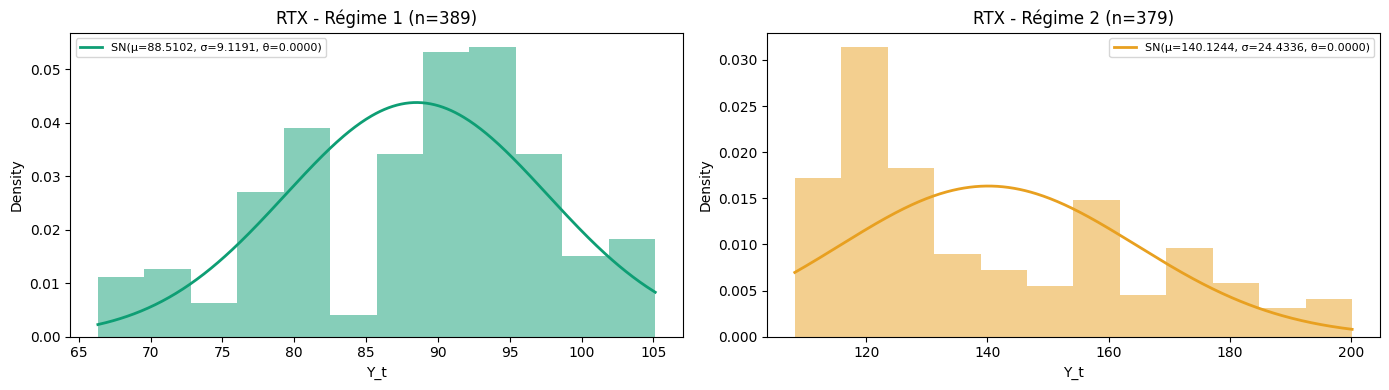

In [29]:
y1 = Y[:k_hat]
y2 = Y[k_hat:]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, seg, mu, sigma, color, label in [
    (axes[0], y1, mu1_hat, sigma1_hat, '#0E9E74', f'Régime 1 (n={len(y1)})'),
    (axes[1], y2, mu2_hat, sigma2_hat, '#E8A020', f'Régime 2 (n={len(y2)})'),
]:
    x_grid = np.linspace(np.min(seg), np.max(seg), 400)
    ax.hist(seg, bins=12, density=True, alpha=0.5, color=color)
    ax.plot(x_grid, skew_normal_pdf(x_grid, mu, sigma, theta_hat),
            color=color, lw=2,
            label=f'SN(μ={mu:.4f}, σ={sigma:.4f}, θ={theta_hat:.4f})')
    ax.set_title(f'RTX - {label}')
    ax.set_xlabel('Y_t'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Interpretation — RTX

In [30]:
interpretation_rtx = (
    f"For RTX, the estimated rupture point is k_hat = {k_hat} "
    f"({break_date.date()}). The KS statistic is {best_ks:.4f} and the "
    f"p-value is {best_pval:.4f}, so the decision is: {verdict_rtx}. "
    f"The joint MLE estimates are mu1 = {mu1_hat:.4f}, sigma1 = {sigma1_hat:.4f}, "
    f"mu2 = {mu2_hat:.4f}, sigma2 = {sigma2_hat:.4f}, theta = {theta_hat:.4f}."
)
print(interpretation_rtx)

For RTX, the estimated rupture point is k_hat = 389 (2024-07-25). The KS statistic is 1.0000 and the p-value is 0.0000, so the decision is: Reject H0. The joint MLE estimates are mu1 = 88.5102, sigma1 = 9.1191, mu2 = 140.1244, sigma2 = 24.4336, theta = 0.0000.


**Save Result as JSON — RTX**

In [31]:
xg1  = np.linspace(y1.min()-0.004, y1.max()+0.004, 300).tolist()
pdf1 = skew_normal_pdf(np.array(xg1), mu1_hat, sigma1_hat, theta_hat).tolist()
xg2  = np.linspace(y2.min()-0.004, y2.max()+0.004, 300).tolist()
pdf2 = skew_normal_pdf(np.array(xg2), mu2_hat, sigma2_hat, theta_hat).tolist()

rtx_results = {
    "company"       : "RTX",
    "name"          : "Dassault Aviation",
    "url"           : "https://fr.finance.yahoo.com/quote/RTX/profile",
    "k_hat"         : int(k_hat),
    "bp_date"       : str(break_date.date()),
    "D"             : round(best_ks, 5),
    "p_value"       : round(best_pval, 6),
    "reject_H0"     : bool(best_pval < 0.05),
    "verdict"       : verdict_rtx,
    "mu1"           : round(mu1_hat, 6),
    "sigma1"        : round(sigma1_hat, 6),
    "mu2"           : round(mu2_hat, 6),
    "sigma2"        : round(sigma2_hat, 6),
    "theta"         : round(theta_hat, 6),
    "n1"            : sn_rtx['n1'],
    "n2"            : sn_rtx['n2'],
    "interpretation": interpretation_rtx,
    "chart_data"    : {
        "dates"   : rtx_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "prices"  : rtx_df["X_t"].tolist(),
        "sm_dates": rtx_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "smoothed": rtx_df["Y_t"].tolist(),
        "Y_dates" : rtx_df["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "Y"       : Y.tolist(),
        "xg1": xg1, "pdf1": pdf1,
        "xg2": xg2, "pdf2": pdf2,
        "scan_k"  : k_values,
        "scan_D"  : ks_stats,
        "scan_p"  : p_values,
    }
}

with open(f"{OUTPUT_DIR}/RTX.json", "w", encoding="utf-8") as f:
    json.dump(rtx_results, f, indent=4, ensure_ascii=False)
print("Saved -> results/json/RTX.json")

Saved -> results/json/RTX.json
